In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from scipy.stats import t as t_dist, norm
from statsmodels.tsa.arima.model import ARIMAResults   # ← add this
from pathlib import Path
import pickle
import json
import warnings
warnings.filterwarnings("ignore")

In [2]:
data_modelled = Path("../../Data/Modelled")
data_sim      = Path("../../Data/Simulated")
models_path   = Path("../../Code/Models")
copula_path   = Path("../../Code/Models/Copula")
output_path   = Path("../../Data/Simulated")
output_path.mkdir(parents=True, exist_ok=True)

In [3]:
# ── simulation constants ───────────────────────────────────────────────────────
START_DATE  = "2026-01-01"
END_DATE    = "2050-12-31"
G_STC       = 1000.0    # W/m² — standard test condition irradiance
PR          = 0.80      # performance ratio
GAMMA       = -0.004    # temperature coefficient /°C
L_FIXED     = 0.6       # logistic lower bound for CR
CRISIS_FLAG = 0         # forward simulation: no crisis
 
print("── Step 0: Configuration ────────────────────────────────────────")
print(f"  Horizon     : {START_DATE} → {END_DATE}")
print(f"  G_STC       : {G_STC} W/m²")
print(f"  PR          : {PR}")
print(f"  γ           : {GAMMA} /°C")
print(f"  L_FIXED CR  : {L_FIXED}")
print(f"  data_modelled: {data_modelled.resolve()}")
print(f"  data_sim     : {data_sim.resolve()}")

── Step 0: Configuration ────────────────────────────────────────
  Horizon     : 2026-01-01 → 2050-12-31
  G_STC       : 1000.0 W/m²
  PR          : 0.8
  γ           : -0.004 /°C
  L_FIXED CR  : 0.6
  data_modelled: C:\Users\LucasMonero\Documents\data projects\Master Thesis\Project\Data\Modelled
  data_sim     : C:\Users\LucasMonero\Documents\data projects\Master Thesis\Project\Data\Simulated


In [4]:
# STEP 1 — Load parameters and innovations
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 1: Load parameters and innovations ──────────────────────")
 
# ── 1.1 copula / marginal parameters ─────────────────────────────────────────
with open(copula_path / "copula_params.pkl", "rb") as f:
    copula_params = pickle.load(f)
nu_copula = int(copula_params["nu"])
print(f"  Copula       : t(ν={nu_copula})")
 
with open(copula_path / "marginal_params.pkl", "rb") as f:
    marginal_params = pickle.load(f)
 
sigma_kt   = float(marginal_params["sigma_kt"])
nu_temp    = float(marginal_params["nu_temp"])
scale_temp = float(marginal_params["scale_temp"])
sigma_temp = float(marginal_params["sigma_temp"])
print(f"  KT marginal  : Gaussian  σ={sigma_kt:.5f}")
print(f"  Temp marginal: t(ν={nu_temp:.2f})  scale={scale_temp:.5f}")


── Step 1: Load parameters and innovations ──────────────────────
  Copula       : t(ν=27)
  KT marginal  : Gaussian  σ=2.33721
  Temp marginal: t(ν=7.45)  scale=0.85807


In [5]:
# ── 1.2 CR model parameters ───────────────────────────────────────────────────
with open(models_path / "Capture rate" / "cr_ar_params.pkl", "rb") as f:
    cr_params = pickle.load(f)
 
nu_cr        = int(cr_params["nu_cr"])
sigma_cr     = float(cr_params["sigma_cr"])
scale_t_cr   = float(cr_params["scale_t"])
phi          = np.array(cr_params["ar_phi"])
N_AR_LAGS    = int(cr_params["ar_n_lags"])
L_FIXED_cr   = float(cr_params["L_FIXED"])
U_FIXED_cr   = float(cr_params["U_FIXED"])
k_fit        = float(cr_params["k"])
pen0_fit     = float(cr_params["pen_0"])
beta_fourier = np.array(cr_params["beta_fourier"])
N_HARMONICS  = int(cr_params["N_harmonics"])
beta_log     = float(cr_params["beta_log"])
beta_sat     = float(cr_params["beta_saturday"])
beta_sun     = float(cr_params["beta_sunday"])
 
print(f"  CR AR(1-{N_AR_LAGS})  : φ₁={phi[0]:+.4f}  φ₇={phi[6]:+.4f}")
print(f"  CR t(ν={nu_cr})   : σ={sigma_cr:.5f}  scale_t={scale_t_cr:.5f}")
print(f"  CR logistic  : L={L_FIXED_cr}  U={U_FIXED_cr:.4f}  "
      f"k={k_fit:.4f}  pen₀={pen0_fit:.4f}")

  CR AR(1-7)  : φ₁=+0.3353  φ₇=+0.2644
  CR t(ν=5)   : σ=0.08019  scale_t=0.06211
  CR logistic  : L=0.6  U=1.2399  k=2.4133  pen₀=0.9818


In [6]:
# ── 1.3 temperature model parameters ─────────────────────────────────────────
with open(models_path / "Temperature" / "temp_model_params.pkl", "rb") as f:
    temp_params = pickle.load(f)
 
ar_temp         = np.array(temp_params["ar_coeffs"])
trend_slope     = float(temp_params["trend_slope"])
trend_ref_year  = float(temp_params["trend_ref_year"])
seasonal_by_doy = temp_params["seasonal_by_doy"]   # dict {doy: °C}
init_ar_resid   = np.array(temp_params["init_ar_resid"])  # [resid(t-1), (t-2)]
init_cond_vol   = float(temp_params["init_cond_vol"])
 
print(f"  Temp AR(2)   : {ar_temp}")
print(f"  Temp trend   : {trend_slope:+.5f}°C/year  ref={trend_ref_year:.0f}")
print(f"  Temp seasonal: {len(seasonal_by_doy)} doy entries  "
      f"[{min(seasonal_by_doy.values()):.1f}, "
      f"{max(seasonal_by_doy.values()):.1f}]°C")
print(f"  Temp init    : {init_ar_resid}")

  Temp AR(2)   : [ 1.03999966 -0.23523774]
  Temp trend   : +0.05453°C/year  ref=2005
  Temp seasonal: 366 doy entries  [-10.8, 11.4]°C
  Temp init    : [-0.43761168 -1.27570549]


In [7]:
# ── 1.4 KT / solar model parameters — LOGIT pipeline ─────────────────────────
# Transformation: Y_t = logit((1-Kt-α)/β)  with α=-0.001, β=0.911
# Seasonal mean : Ȳ_t = a0 + a1·cos(2πt/365) + a2·sin(2πt/365)
#                 t = absolute day index from 2005-01-01 (NOT doy)
# ARMA(2,1)     : AR=[1.2977, -0.3397]  MA=[-0.8998]
 
# load ARMA fitted result
arma_result = ARIMAResults.load(
    str(models_path / "GHI - KT" / "ghi_arma_result.pkl")
)
arma_phi   = arma_result.arparams     # AR coefficients [φ1, φ2]
arma_theta = arma_result.maparams     # MA coefficient  [θ1]
 
# load Fourier seasonal coefficients [a0, a1, a2]
with open(models_path / "GHI - KT" /"ghi_seasonal_coeffs.pkl", "rb") as f:
    a_seasonal = np.array(pickle.load(f))
 
# load logit transform parameters
with open(models_path / "GHI - KT" / "model_meta.json", "r") as f:
    meta = json.load(f)
alpha_kt = float(meta["logit_transform"]["alpha"])   # -0.001000
beta_kt  = float(meta["logit_transform"]["beta"])    # 0.911341
 
print(f"  KT ARMA(2,1) : AR={np.round(arma_phi,4)}  MA={np.round(arma_theta,4)}")
print(f"  KT seasonal  : a=[{a_seasonal[0]:.4f}, "
      f"{a_seasonal[1]:.4f}, {a_seasonal[2]:.4f}]")
print(f"  KT logit     : α={alpha_kt:.6f}  β={beta_kt:.6f}")

  KT ARMA(2,1) : AR=[ 1.2977 -0.3397]  MA=[-0.8998]
  KT seasonal  : a=[-2.1033, 0.8836, 0.2350]
  KT logit     : α=-0.001000  β=0.911341


In [8]:
# ── 1.5 load raw copula innovations ──────────────────────────────────────────
print(f"\n  Loading mc_innovations.parquet...")
df_innov = pd.read_parquet(data_sim / "mc_innovations.parquet")
df_innov["date"] = pd.to_datetime(df_innov["date"])
 
N_SIM  = int(df_innov["sim_id"].nunique())
N_DAYS = int(df_innov.groupby("sim_id").size().iloc[0])
print(f"  Innovations  : {N_SIM} paths × {N_DAYS} days")
print(f"  Date range   : {df_innov['date'].min().date()} → "
      f"{df_innov['date'].max().date()}")
 
df_innov_sorted = df_innov.sort_values(["sim_id", "date"]).reset_index(drop=True)
eps_cr_raw   = df_innov_sorted["eps_cr"].values.reshape(N_SIM, N_DAYS)
eps_kt_raw   = df_innov_sorted["eps_kt"].values.reshape(N_SIM, N_DAYS)
eps_temp_raw = df_innov_sorted["eps_temp"].values.reshape(N_SIM, N_DAYS)
dates_sim    = np.sort(pd.to_datetime(df_innov_sorted["date"].unique()))
print(f"  Arrays shaped: (N_SIM={N_SIM}, N_DAYS={N_DAYS})")


  Loading mc_innovations.parquet...
  Innovations  : 1000 paths × 9131 days
  Date range   : 2026-01-01 → 2050-12-31
  Arrays shaped: (N_SIM=1000, N_DAYS=9131)


In [9]:
# ── 1.6 load historical data for state initialisation ─────────────────────────
print(f"\n  Loading historical modelled data...")
 
df_cr_hist = pd.read_parquet(data_modelled / "df_cr_modelled.parquet")
df_cr_hist["date"] = pd.to_datetime(df_cr_hist["date"])
df_cr_hist = df_cr_hist.sort_values("date").reset_index(drop=True)
 
df_solar_hist = pd.read_parquet(data_modelled / "df_solar_modelled.parquet")
df_solar_hist = df_solar_hist.reset_index()
df_solar_hist["date"] = pd.to_datetime(df_solar_hist["date"])
df_solar_hist = df_solar_hist.sort_values("date").reset_index(drop=True)
 
df_temp_hist = pd.read_parquet(data_modelled / "df_temperature_modeled.parquet")
df_temp_hist["date"] = pd.to_datetime(df_temp_hist["date"])
df_temp_hist = df_temp_hist.sort_values("date").reset_index(drop=True)
 
# historical length — needed for absolute day index in solar seasonal mean
hist_n_days = len(df_solar_hist)   # should be 7670 (2005-01-01 to 2025-12-31)
 
print(f"  CR hist      : {len(df_cr_hist)} rows  "
      f"{df_cr_hist['date'].max().date()}")
print(f"  Solar hist   : {hist_n_days} rows  "
      f"{df_solar_hist['date'].max().date()}")
print(f"  Temp hist    : {len(df_temp_hist)} rows  "
      f"{df_temp_hist['date'].max().date()}")
print(f"  hist_n_days  : {hist_n_days}  "
      f"(sim starts at absolute day {hist_n_days})")


  Loading historical modelled data...
  CR hist      : 7670 rows  2025-12-31
  Solar hist   : 7670 rows  2025-12-31
  Temp hist    : 7670 rows  2025-12-31
  hist_n_days  : 7670  (sim starts at absolute day 7670)


In [10]:
# STEP 2 — Build simulation calendar and penetration scenario
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 2: Simulation calendar and penetration scenario ─────────")

# ── 2.1 simulation calendar ───────────────────────────────────────────────────
dates_pd = pd.date_range(start=START_DATE, end=END_DATE, freq="D")
assert len(dates_pd) == N_DAYS, \
    f"Calendar {len(dates_pd)} ≠ innovations {N_DAYS}"
 
df_cal = pd.DataFrame({
    "date":         dates_pd,
    "year":         dates_pd.year,
    "month":        dates_pd.month,
    "doy":          dates_pd.dayofyear,
    "weekday":      dates_pd.weekday,
    "decimal_year": dates_pd.year + (dates_pd.dayofyear - 1) / 365.0,
    "t_year":       (dates_pd.dayofyear - 1) / 365.0,
    "is_saturday":  (dates_pd.weekday == 5).astype(int),
    "is_sunday":    (dates_pd.weekday == 6).astype(int),
})
 
# absolute day index: used by solar seasonal mean
# historical series day 0 = 2005-01-01, day 7669 = 2025-12-31
# simulation day 0 = 2026-01-01 = absolute index hist_n_days
t_abs_sim = np.arange(hist_n_days, hist_n_days + N_DAYS)
df_cal["t_abs"] = t_abs_sim
 
print(f"  Calendar     : {len(df_cal)} days  ({START_DATE} → {END_DATE})")
print(f"  t_abs range  : [{t_abs_sim[0]}, {t_abs_sim[-1]}]")


── Step 2: Simulation calendar and penetration scenario ─────────
  Calendar     : 9131 days  (2026-01-01 → 2050-12-31)
  t_abs range  : [7670, 16800]


In [11]:
# ── 2.2 penetration scenario: logistic from ~1.0 in 2026 to 1.5 in 2050 ──────

# load solar share from cleaned data
df_solar_share  = pd.read_parquet(
    Path("../../Data/Cleaned/df_solar_share.parquet")
)
REFERENCE_SHARE = float(df_solar_share["solar_share_pct"].max())
solar_share_pct = dict(zip(
    df_solar_share["year"],
    df_solar_share["solar_share_pct"]
))

print(f"\n  Solar share loaded: {len(df_solar_share)} years  "
      f"({df_solar_share['year'].min()}–{df_solar_share['year'].max()})")
print(f"  Reference share   : {REFERENCE_SHARE}%  "
      f"(max observed = {df_solar_share.loc[df_solar_share['solar_share_pct'].idxmax(), 'year']})")
print(f"  pen=1.0 anchored at {REFERENCE_SHARE}% solar share")

# target scenario: 50% above reference by 2050
PEN_START = float(
    df_solar_share.loc[df_solar_share["year"] == 2025, "solar_share_pct"].iloc[0]
) / REFERENCE_SHARE   # current level relative to new reference
# target scenario: solar share reaches 50% by 2050
PEN_END = 50.0 / REFERENCE_SHARE   # 50% solar share / reference share

t_mid_pen = 2038.0
k_pen     = 0.4

def logistic_pen(t, t_mid, k, lo, hi):
    return lo + (hi - lo) / (1 + np.exp(-k * (t - t_mid)))

pen_scenario = logistic_pen(
    df_cal["decimal_year"].values, t_mid_pen, k_pen, PEN_START, PEN_END
)
df_cal["pen_scenario"] = pen_scenario

print(f"\n  Penetration scenario (logistic — solar share → 50% by 2050):")
print(f"    PEN_START = {PEN_START:.4f}  "
      f"({PEN_START * REFERENCE_SHARE:.2f}% solar share in 2024)")
print(f"    PEN_END   = {PEN_END:.4f}  "
      f"(50.0% solar share in 2050  /  ref={REFERENCE_SHARE}%)")
print(f"    k         = {k_pen}  midpoint = {t_mid_pen}")
print(f"    pen(2026) = {pen_scenario[0]:.4f}  "
      f"≈ {pen_scenario[0]*REFERENCE_SHARE:.1f}% solar share")
print(f"    pen(2035) = {pen_scenario[df_cal['year']==2035].mean():.4f}  "
      f"≈ {pen_scenario[df_cal['year']==2035].mean()*REFERENCE_SHARE:.1f}%")
print(f"    pen(2040) = {pen_scenario[df_cal['year']==2040].mean():.4f}  "
      f"≈ {pen_scenario[df_cal['year']==2040].mean()*REFERENCE_SHARE:.1f}%")
print(f"    pen(2050) = {pen_scenario[-1]:.4f}  "
      f"≈ {pen_scenario[-1]*REFERENCE_SHARE:.1f}% solar share")


  Solar share loaded: 21 years  (2005–2025)
  Reference share   : 13.0%  (max observed = 2025)
  pen=1.0 anchored at 13.0% solar share

  Penetration scenario (logistic — solar share → 50% by 2050):
    PEN_START = 1.0000  (13.00% solar share in 2024)
    PEN_END   = 3.8462  (50.0% solar share in 2050  /  ref=13.0%)
    k         = 0.4  midpoint = 2038.0
    pen(2026) = 1.0232  ≈ 13.3% solar share
    pen(2035) = 1.7669  ≈ 23.0%
    pen(2040) = 3.0790  ≈ 40.0%
    pen(2050) = 3.8305  ≈ 49.8% solar share


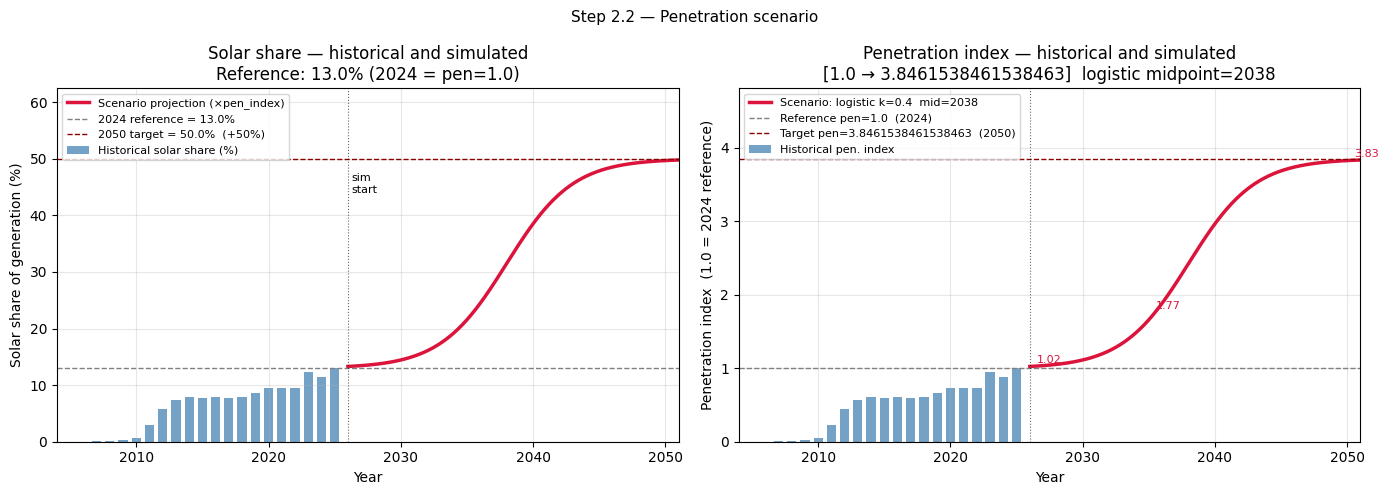

In [12]:
# ── penetration scenario plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── left panel: solar share % ─────────────────────────────────────────────────
ax = axes[0]

# historical solar share in %
hist_years  = np.array(sorted(solar_share_pct.keys()))
hist_share  = np.array([solar_share_pct[y] for y in hist_years])

# simulated solar share = pen_scenario × REFERENCE_SHARE
sim_share   = pen_scenario * REFERENCE_SHARE

ax.bar(hist_years, hist_share, color="steelblue", alpha=0.75,
       width=0.7, label="Historical solar share (%)")
ax.plot(df_cal["decimal_year"].values, sim_share,
        color="crimson", lw=2.5,
        label=f"Scenario projection (×pen_index)")
ax.axhline(REFERENCE_SHARE, color="grey", lw=1.0, ls="--",
           label=f"2024 reference = {REFERENCE_SHARE}%")
ax.axhline(REFERENCE_SHARE * PEN_END, color="darkred", lw=1.0, ls="--",
           label=f"2050 target = {REFERENCE_SHARE * PEN_END:.1f}%  (+50%)")
ax.axvline(2026, color="black", lw=0.8, ls=":", alpha=0.6)
ax.text(2026.3, REFERENCE_SHARE * PEN_END * 0.88,
        "sim\nstart", fontsize=8, color="black")

ax.set_xlabel("Year")
ax.set_ylabel("Solar share of generation (%)")
ax.set_title("Solar share — historical and simulated\n"
             f"Reference: {REFERENCE_SHARE}% (2024 = pen=1.0)")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(2004, 2051)
ax.set_ylim(0, REFERENCE_SHARE * PEN_END * 1.25)
ax.grid(alpha=0.3)

# ── right panel: penetration index ────────────────────────────────────────────
ax = axes[1]

hist_pen = hist_share / REFERENCE_SHARE

ax.bar(hist_years, hist_pen, color="steelblue", alpha=0.75,
       width=0.7, label="Historical pen. index")
ax.plot(df_cal["decimal_year"].values, pen_scenario,
        color="crimson", lw=2.5,
        label=f"Scenario: logistic k={k_pen}  mid={t_mid_pen:.0f}")
ax.axhline(1.0, color="grey", lw=1.0, ls="--",
           label=f"Reference pen=1.0  (2024)")
ax.axhline(PEN_END, color="darkred", lw=1.0, ls="--",
           label=f"Target pen={PEN_END}  (2050)")
ax.axvline(2026, color="black", lw=0.8, ls=":", alpha=0.6)

# annotate key values
for yr, label in [(2026, f"{pen_scenario[0]:.2f}"),
                   (2035, f"{pen_scenario[df_cal['year']==2035].mean():.2f}"),
                   (2050, f"{pen_scenario[-1]:.2f}")]:
    idx  = df_cal["year"] == yr
    y_val = pen_scenario[idx].mean() if yr != 2050 else pen_scenario[-1]
    ax.annotate(label,
                xy=(yr, y_val),
                xytext=(yr + 0.5, y_val + 0.04),
                fontsize=8, color="crimson")

ax.set_xlabel("Year")
ax.set_ylabel("Penetration index  (1.0 = 2024 reference)")
ax.set_title("Penetration index — historical and simulated\n"
             f"[{PEN_START} → {PEN_END}]  logistic midpoint={t_mid_pen:.0f}")
ax.legend(fontsize=8, loc="upper left")
ax.set_xlim(2004, 2051)
ax.set_ylim(0, PEN_END * 1.25)
ax.grid(alpha=0.3)

plt.suptitle("Step 2.2 — Penetration scenario", fontsize=11)
plt.tight_layout()
plt.show()

In [13]:
# ── 2.3 clear-sky GHI by day-of-year ─────────────────────────────────────────
ghi_cs_col = None
for c in ["GHI_cs_sum", "ghi_cs_sum", "GHI_clearsky"]:
    if c in df_solar_hist.columns:
        ghi_cs_col = c
        break
if ghi_cs_col is None and "ghi_cs_sum" in df_cr_hist.columns:
    ghi_cs_col = "ghi_cs_sum"
    df_solar_hist = df_solar_hist.merge(
        df_cr_hist[["date", "ghi_cs_sum"]], on="date", how="left"
    )
 
df_solar_hist["doy"] = df_solar_hist["date"].dt.dayofyear
ghi_cs_doy = df_solar_hist.groupby("doy")[ghi_cs_col].mean()
 
ghi_clearsky_sim = np.array([
    ghi_cs_doy.get(int(d), float(ghi_cs_doy.mean()))
    for d in df_cal["doy"].values
])
df_cal["ghi_clearsky"] = ghi_clearsky_sim
print(f"\n  Clear-sky GHI: [{ghi_clearsky_sim.min():.0f}, "
      f"{ghi_clearsky_sim.max():.0f}] Wh/m²  "
      f"mean={ghi_clearsky_sim.mean():.0f}")


  Clear-sky GHI: [1889, 8320] Wh/m²  mean=5201


In [14]:
# ── 2.4 temperature seasonal mean from temp_model_params ─────────────────────
temp_seasonal_sim = np.array([
    seasonal_by_doy.get(int(doy), 10.0)
    + trend_slope * (yr - trend_ref_year)
    for doy, yr in zip(df_cal["doy"].values, df_cal["year"].values)
])
df_cal["temp_seasonal_sim"] = temp_seasonal_sim
print(f"  Temp seasonal: [{temp_seasonal_sim.min():.1f}, "
      f"{temp_seasonal_sim.max():.1f}]°C  "
      f"(+{trend_slope:.3f}°C/year)")

  Temp seasonal: [-9.6, 13.9]°C  (+0.055°C/year)


In [15]:
# ── 2.5 solar Ȳ_t seasonal mean (absolute day index) ─────────────────────────
X_seas_sim = np.column_stack([
    np.ones(N_DAYS),
    np.cos(2 * np.pi * t_abs_sim / 365),
    np.sin(2 * np.pi * t_abs_sim / 365),
])
Y_bar_sim = X_seas_sim @ a_seasonal   # shape (N_DAYS,)
print(f"  KT Y_bar_sim : [{Y_bar_sim.min():.3f}, {Y_bar_sim.max():.3f}]")

  KT Y_bar_sim : [-3.018, -1.189]


In [16]:
# ── 2.6 precompute deterministic CR mean ──────────────────────────────────────
t_year_arr    = df_cal["t_year"].values
X_fourier_sim = np.column_stack([np.ones(N_DAYS)] + [
    f(2 * np.pi * k * t_year_arr)
    for k in range(1, N_HARMONICS + 1)
    for f in (np.cos, np.sin)
])
fourier_component = X_fourier_sim @ beta_fourier
 
def logistic_cr(pen, k, pen0, L, U):
    return L + (U - L) / (1 + np.exp(k * (pen - pen0)))
 
logistic_component = beta_log * logistic_cr(
    pen_scenario, k_fit, pen0_fit, L_FIXED_cr, U_FIXED_cr
)
 
mu_CR_sim = (
    fourier_component
    + logistic_component
    + beta_sat * df_cal["is_saturday"].values.astype(float)
    + beta_sun * df_cal["is_sunday"].values.astype(float)
)
df_cal["mu_CR_sim"] = mu_CR_sim
 
print(f"  μ_CR 2026    : {mu_CR_sim[df_cal['year']==2026].mean():.4f}")
print(f"  μ_CR 2035    : {mu_CR_sim[df_cal['year']==2035].mean():.4f}")
print(f"  μ_CR 2050    : {mu_CR_sim[df_cal['year']==2050].mean():.4f}")

  μ_CR 2026    : 0.8910
  μ_CR 2035    : 0.6529
  μ_CR 2050    : 0.5611


In [17]:
# ── 2.7 state vector initialisation ──────────────────────────────────────────
# CR: last 7 observed CR_resid
cr_init = df_cr_hist["CR_resid"].dropna().values[-N_AR_LAGS:]
print(f"\n  CR init      : {cr_init}")
 
# KT: last 2 Ỹ_t values and last ε for MA(1) memory
ytilde_col = next((c for c in ["Y_tilde", "Ytilde"] if c in df_solar_hist.columns), None)
eps_col    = next((c for c in ["epsilon", "eps_kt"] if c in df_solar_hist.columns), None)
 
if ytilde_col and eps_col:
    kt_ytilde_init = df_solar_hist[ytilde_col].dropna().values[-2:]
    kt_eps_init    = float(df_solar_hist[eps_col].dropna().values[-1])
    print(f"  KT Ỹ init    : {kt_ytilde_init}")
    print(f"  KT ε init    : {kt_eps_init:.4f}")
else:
    kt_ytilde_init = np.array([0.0, 0.0])
    kt_eps_init    = 0.0
    print(f"  KT init      : zeros  "
          f"(cols not found — available: {list(df_solar_hist.columns)})")
 
# Temp: from temp_model_params
temp_ar_init = init_ar_resid.copy()   # [resid(t-1), resid(t-2)]
print(f"  Temp init    : {temp_ar_init}")


  CR init      : [ 0.01620101 -0.01395078 -0.03937718  0.02214592 -0.014366    0.00610236
 -0.00479355]
  KT Ỹ init    : [ 0.60115335 -1.67096842]
  KT ε init    : -1.8681
  Temp init    : [-0.43761168 -1.27570549]


In [22]:
# STEP 3 — Reconstruct T_sim(t)  [°C]
# ─────────────────────────────────────────────────────────────────────────────
# ε_temp(t) [copula innovation on t(ν_temp) scale]
# → AR(2) propagation → stochastic temperature residual
# → add STL seasonal mean + warming trend → T_sim(t)
 
print(f"\n── Step 3: Reconstruct T_sim(t) ─────────────────────────────────")
 
T_sim = np.zeros((N_SIM, N_DAYS))
 
for sim_id in range(N_SIM):
    resid_prev = temp_ar_init.copy()   # [r(t-1), r(t-2)]
 
    for t in range(N_DAYS):
        innovation = eps_temp_raw[sim_id, t]   # on t(ν_temp) scale
        resid_t    = (ar_temp[0] * resid_prev[0]
                    + ar_temp[1] * resid_prev[1]
                    + innovation)
        T_sim[sim_id, t] = temp_seasonal_sim[t] + resid_t
        resid_prev = np.array([resid_t, resid_prev[0]])
 
    if (sim_id + 1) % 200 == 0:
        print(f"  T_sim: {sim_id+1}/{N_SIM}")
 
T_flat = T_sim.ravel()
print(f"  T_sim mean={T_flat.mean():.2f}°C  std={T_flat.std():.2f}°C  "
      f"p5={np.percentile(T_flat,5):.1f}°C  p95={np.percentile(T_flat,95):.1f}°C")


── Step 3: Reconstruct T_sim(t) ─────────────────────────────────
  T_sim: 200/1000
  T_sim: 400/1000
  T_sim: 600/1000
  T_sim: 800/1000
  T_sim: 1000/1000
  T_sim mean=14.62°C  std=7.61°C  p5=3.3°C  p95=26.1°C


  df_temp_hist columns: ['date', 't2m_mean', 't2m_min', 't2m_max', 't2m_range', 'arch_resid', 'arch_std_resid', 'arch_cond_vol', 'arch_predicted']
  Historical T column : 't2m_mean'
  Historical T range  : 11.89°C – 14.15°C


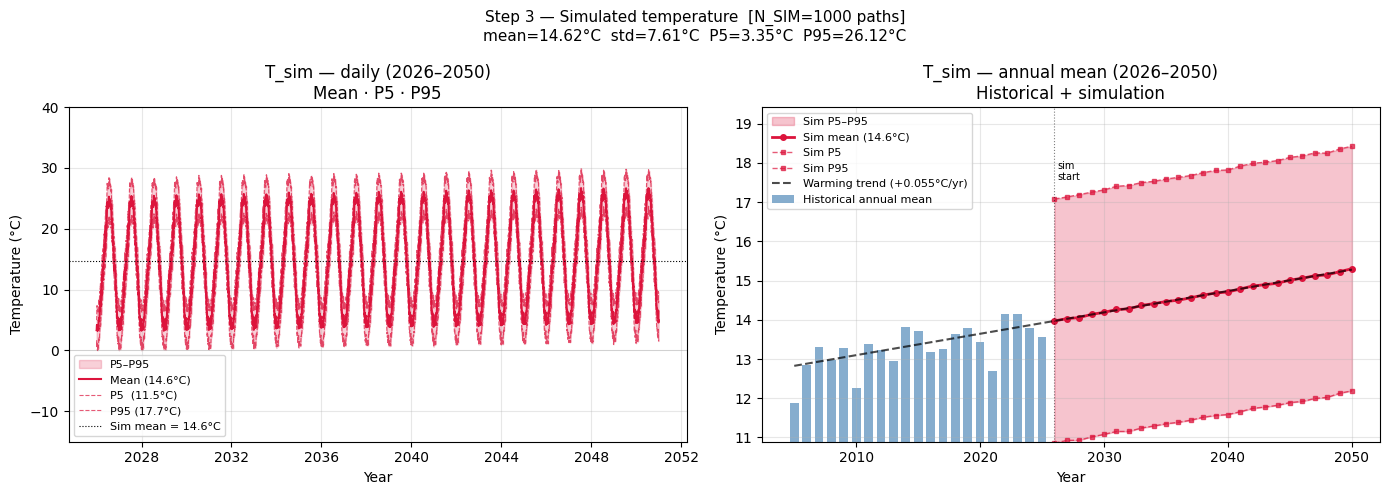

In [ ]:
# ── T_sim fan chart ───────────────────────────────────────────────────────────
T_mean = T_sim.mean(axis=0)
T_p5   = np.percentile(T_sim,  5, axis=0)
T_p95  = np.percentile(T_sim, 95, axis=0)

# annual aggregation for cleaner plot
df_T_plot = pd.DataFrame({
    "date":  dates_pd,
    "mean":  T_mean,
    "p5":    T_p5,
    "p95":   T_p95,
    "year":  dates_pd.year,
})
T_annual = df_T_plot.groupby("year")[["mean", "p5", "p95"]].mean()

# ── historical annual mean temperature ────────────────────────────────────────
print(f"  df_temp_hist columns: {list(df_temp_hist.columns)}")

temp_col_hist = next(
    (c for c in ["t2m_mean", "t2m_daily", "t2m",
                  "temp_mean", "T_mean", "temperature"]
     if c in df_temp_hist.columns), None
)

if temp_col_hist:
    df_temp_hist["year_col"] = pd.to_datetime(
        df_temp_hist["date"]
    ).dt.year
    T_hist_annual = (
        df_temp_hist.groupby("year_col")[temp_col_hist].mean()
    )
    T_hist_annual.index.name = "year"
    print(f"  Historical T column : '{temp_col_hist}'")
    print(f"  Historical T range  : "
          f"{T_hist_annual.min():.2f}°C – {T_hist_annual.max():.2f}°C")
else:
    T_hist_annual = None
    print(f"  WARNING: no temperature column found in df_temp_hist")
    print(f"  Columns available   : {list(df_temp_hist.columns)}")

# ── warming trend over full range ─────────────────────────────────────────────
if T_hist_annual is not None:
    all_years = np.concatenate([
        T_hist_annual.index.values.astype(float),
        T_annual.index.values.astype(float),
    ])
else:
    all_years = T_annual.index.values.astype(float)

trend_line = trend_intercept + trend_slope * (all_years + 0.5)

# ── figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── left: daily fan chart ─────────────────────────────────────────────────────
ax = axes[0]
ax.fill_between(dates_pd, T_p5, T_p95,
                alpha=0.20, color="crimson", label="P5–P95")
ax.plot(dates_pd, T_mean,
        color="crimson", lw=1.5, label=f"Mean ({T_mean.mean():.1f}°C)")
ax.plot(dates_pd, T_p5,
        color="crimson", lw=0.8, ls="--", alpha=0.7,
        label=f"P5  ({T_p5.mean():.1f}°C)")
ax.plot(dates_pd, T_p95,
        color="crimson", lw=0.8, ls="--", alpha=0.7,
        label=f"P95 ({T_p95.mean():.1f}°C)")
ax.axhline(T_flat.mean(), color="black", lw=0.8, ls=":",
           label=f"Sim mean = {T_flat.mean():.1f}°C")
ax.axhline(0, color="grey", lw=0.5, ls="-", alpha=0.3)

ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.set_title("T_sim — daily (2026–2050)\nMean · P5 · P95")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_ylim(
    min(-15, float(T_p5.min()) - 2),
    max(40,  float(T_p95.max()) + 2)
)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── right: annual mean — historical bars + simulation fan ─────────────────────
ax = axes[1]

# historical bars
if T_hist_annual is not None:
    ax.bar(T_hist_annual.index, T_hist_annual.values,
           color="steelblue", alpha=0.65, width=0.7,
           label="Historical annual mean")

# simulation fan
ax.fill_between(T_annual.index, T_annual["p5"], T_annual["p95"],
                alpha=0.25, color="crimson", label="Sim P5–P95")
ax.plot(T_annual.index, T_annual["mean"], "o-",
        color="crimson", lw=2.0, ms=4,
        label=f"Sim mean ({T_annual['mean'].mean():.1f}°C)")
ax.plot(T_annual.index, T_annual["p5"],  "s--",
        color="crimson", lw=1.0, ms=3, alpha=0.7, label="Sim P5")
ax.plot(T_annual.index, T_annual["p95"], "s--",
        color="crimson", lw=1.0, ms=3, alpha=0.7, label="Sim P95")

# warming trend over full horizon
ax.plot(all_years, trend_line,
        color="black", lw=1.5, ls="--", alpha=0.7,
        label=f"Warming trend (+{trend_slope:.3f}°C/yr)")

# vertical marker at simulation start
ax.axvline(2026, color="black", lw=0.8, ls=":", alpha=0.5)
ax.text(2026.2,
        T_annual["p95"].max() * 0.98,
        "sim\nstart", fontsize=7, color="black",
        va="top")

ax.set_xlabel("Year")
ax.set_ylabel("Temperature (°C)")
ax.set_title("T_sim — annual mean (2026–2050)\nHistorical + simulation")

# dynamic y-axis based on actual values
y_lo = (T_hist_annual.min() - 1) if T_hist_annual is not None \
       else T_annual["p5"].min() - 1
y_hi = max(T_annual["p95"].max(), trend_line.max()) + 1
ax.set_ylim(y_lo, y_hi)

ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)

# ── suptitle ──────────────────────────────────────────────────────────────────
plt.suptitle(
    f"Step 3 — Simulated temperature  [N_SIM={N_SIM} paths]\n"
    f"mean={T_flat.mean():.2f}°C  "
    f"std={T_flat.std():.2f}°C  "
    f"P5={np.percentile(T_flat, 5):.2f}°C  "
    f"P95={np.percentile(T_flat, 95):.2f}°C",
    fontsize=11
)
plt.tight_layout()
plt.show()


  Annual mean T in 2050 — distribution across 1000 paths:
    mean  = 15.303°C
    std   = 0.262°C
    P5    = 14.894°C
    P25   = 15.118°C
    P50   = 15.304°C
    P75   = 15.476°C
    P95   = 15.744°C
    min   = 14.496°C
    max   = 16.168°C


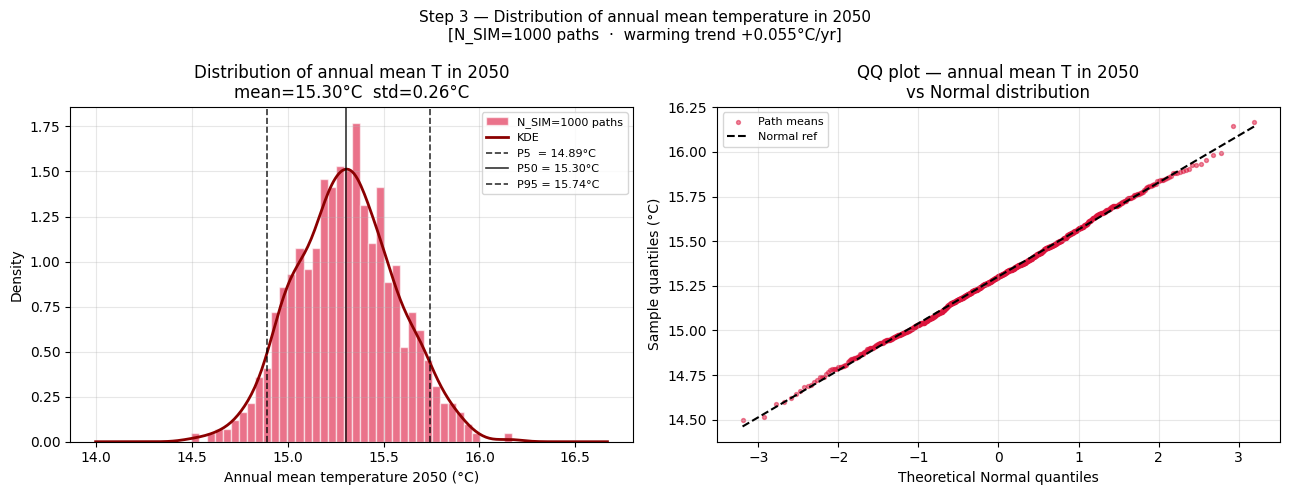

In [24]:
# ── distribution of mean annual temperature in 2050 ──────────────────────────
mask_2050   = df_T_plot["year"] == 2050
T_2050_daily = T_sim[:, mask_2050.values]        # (N_SIM, days_in_2050)
T_2050_mean  = T_2050_daily.mean(axis=1)          # (N_SIM,) annual mean per path

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── left: histogram + KDE ─────────────────────────────────────────────────────
ax = axes[0]
ax.hist(T_2050_mean, bins=40, density=True,
        color="crimson", alpha=0.6, edgecolor="white",
        label=f"N_SIM={N_SIM} paths")

from scipy.stats import gaussian_kde
kde  = gaussian_kde(T_2050_mean)
x_g  = np.linspace(T_2050_mean.min() - 0.5,
                    T_2050_mean.max() + 0.5, 300)
ax.plot(x_g, kde(x_g), color="darkred", lw=2.0, label="KDE")

# percentile markers
for pct, ls, label in [
    ( 5, "--", f"P5  = {np.percentile(T_2050_mean,  5):.2f}°C"),
    (50, "-",  f"P50 = {np.percentile(T_2050_mean, 50):.2f}°C"),
    (95, "--", f"P95 = {np.percentile(T_2050_mean, 95):.2f}°C"),
]:
    ax.axvline(np.percentile(T_2050_mean, pct),
               color="black", lw=1.2, ls=ls, alpha=0.8, label=label)

ax.set_xlabel("Annual mean temperature 2050 (°C)")
ax.set_ylabel("Density")
ax.set_title("Distribution of annual mean T in 2050\n"
             f"mean={T_2050_mean.mean():.2f}°C  "
             f"std={T_2050_mean.std():.2f}°C")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── right: QQ plot vs normal ──────────────────────────────────────────────────
ax = axes[1]
from scipy.stats import probplot
(osm, osr) = probplot(T_2050_mean, dist="norm", fit=False)
osm = np.array(osm)
osr = np.array(osr)
ax.scatter(osm, osr, s=8, alpha=0.5, color="crimson", label="Path means")
slope_q, int_q = np.polyfit(osm, osr, 1)
ax.plot(osm, slope_q * osm + int_q,
        color="black", lw=1.5, ls="--", label="Normal ref")
ax.set_xlabel("Theoretical Normal quantiles")
ax.set_ylabel("Sample quantiles (°C)")
ax.set_title("QQ plot — annual mean T in 2050\nvs Normal distribution")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# summary stats
print(f"\n  Annual mean T in 2050 — distribution across {N_SIM} paths:")
print(f"    mean  = {T_2050_mean.mean():.3f}°C")
print(f"    std   = {T_2050_mean.std():.3f}°C")
print(f"    P5    = {np.percentile(T_2050_mean,  5):.3f}°C")
print(f"    P25   = {np.percentile(T_2050_mean, 25):.3f}°C")
print(f"    P50   = {np.percentile(T_2050_mean, 50):.3f}°C")
print(f"    P75   = {np.percentile(T_2050_mean, 75):.3f}°C")
print(f"    P95   = {np.percentile(T_2050_mean, 95):.3f}°C")
print(f"    min   = {T_2050_mean.min():.3f}°C")
print(f"    max   = {T_2050_mean.max():.3f}°C")

plt.suptitle(
    f"Step 3 — Distribution of annual mean temperature in 2050\n"
    f"[N_SIM={N_SIM} paths  ·  warming trend +{trend_slope:.3f}°C/yr]",
    fontsize=11
)
plt.tight_layout()
plt.show()

In [26]:
# STEP 4 — Reconstruct GHI_sim(t) via KT_sim(t)  [Wh/m²]
# ─────────────────────────────────────────────────────────────────────────────
# ε_KT(t) [copula innovation, Gaussian scale = ARMA residual in Ỹ_t space]
# → ARMA(2,1) propagation → Ỹ_t
# → add Ȳ_t (Fourier seasonal, absolute day index) → Y_t
# → invert logit → Kt_sim(t) ∈ (0,1)
# → GHI_sim(t) = Kt_sim(t) × GHI_clearsky(t)
 
print(f"\n── Step 4: Reconstruct GHI_sim(t) ──────────────────────────────")
 
def invert_logit_to_kt(Y_t, alpha, beta):
    """Recover Kt from Y_t = logit(X'_t) where X'_t = (1-Kt-alpha)/beta."""
    Xp = 1.0 / (1.0 + np.exp(-Y_t))
    Xt = alpha + beta * Xp
    return float(np.clip(1.0 - Xt, 0.001, 0.999))
 
KT_sim  = np.zeros((N_SIM, N_DAYS))
GHI_sim = np.zeros((N_SIM, N_DAYS))
 
for sim_id in range(N_SIM):
    ytilde_prev = kt_ytilde_init.copy()   # [Ỹ(t-1), Ỹ(t-2)]
    eps_prev    = kt_eps_init             # ε(t-1) for MA(1)
 
    for t in range(N_DAYS):
        eps_t = eps_kt_raw[sim_id, t]   # Gaussian innovation
 
        # ARMA(2,1) in Ỹ_t space
        ytilde_t = (arma_phi[0]   * ytilde_prev[0]
                  + arma_phi[1]   * ytilde_prev[1]
                  + eps_t
                  + arma_theta[0] * eps_prev)
 
        # add Fourier seasonal mean (absolute day index)
        Y_t  = ytilde_t + Y_bar_sim[t]
 
        # invert logit → Kt
        kt_t = invert_logit_to_kt(Y_t, alpha_kt, beta_kt)
 
        KT_sim[sim_id, t]  = kt_t
        GHI_sim[sim_id, t] = kt_t * ghi_clearsky_sim[t]
 
        ytilde_prev = np.array([ytilde_t, ytilde_prev[0]])
        eps_prev    = eps_t
 
    if (sim_id + 1) % 200 == 0:
        print(f"  GHI_sim: {sim_id+1}/{N_SIM}")
 
KT_flat  = KT_sim.ravel()
GHI_flat = GHI_sim.ravel()
print(f"  KT_sim  mean={KT_flat.mean():.4f}  "
      f"p5={np.percentile(KT_flat,5):.4f}  p95={np.percentile(KT_flat,95):.4f}")
print(f"  GHI_sim mean={GHI_flat.mean():.0f} Wh/m²  "
      f"p5={np.percentile(GHI_flat,5):.0f}  p95={np.percentile(GHI_flat,95):.0f}")


── Step 4: Reconstruct GHI_sim(t) ──────────────────────────────
  GHI_sim: 200/1000
  GHI_sim: 400/1000
  GHI_sim: 600/1000
  GHI_sim: 800/1000
  GHI_sim: 1000/1000
  KT_sim  mean=0.7682  p5=0.1736  p95=0.9990
  GHI_sim mean=4124 Wh/m²  p5=604  p95=8003


  Historical GHI column : 'ghi_sum'  n=7670
  Historical GHI range  : [192, 8898] Wh/m²

  Simulated GHI (all paths, non-zero):
    n      = 9,131,000
    mean   = 4124 Wh/m²
    std    = 2452 Wh/m²
    P5     = 604 Wh/m²
    P50    = 3820 Wh/m²
    P95    = 8003 Wh/m²

  Historical GHI (non-zero):
    n      = 7,670
    mean   = 4083 Wh/m²
    std    = 2442 Wh/m²
    P5     = 657 Wh/m²
    P50    = 3825 Wh/m²
    P95    = 8042 Wh/m²

  KS test (hist vs sim, n=5000 each):
    stat=0.0280  p=0.0397  ✗ distributions differ


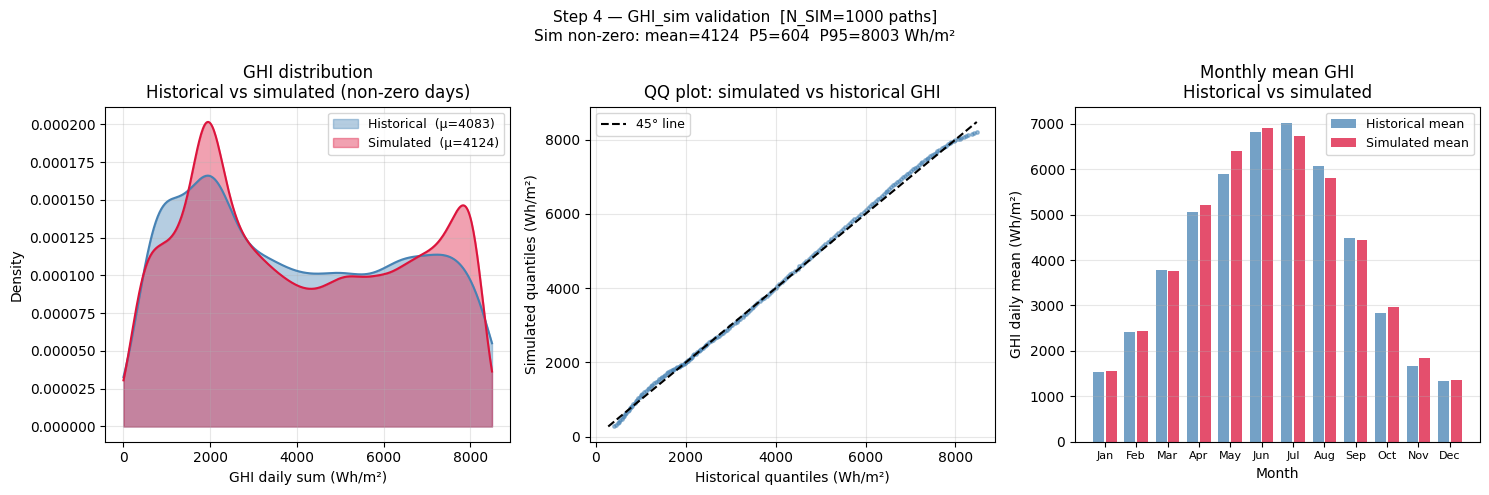

In [27]:
# ── GHI_sim validation against historical ────────────────────────────────────

# load historical GHI from df_cr_modelled (has ghi_sum column)
ghi_hist_col = next(
    (c for c in ["ghi_sum", "GHI_sum", "GHI_daily_sum", "ghi_daily"]
     if c in df_cr_hist.columns), None
)

if ghi_hist_col is None:
    # try df_solar_hist
    ghi_hist_col = next(
        (c for c in ["ghi_sum", "GHI_sum", "GHI"]
         if c in df_solar_hist.columns), None
    )
    df_ghi_hist = df_solar_hist[["date", ghi_hist_col]].copy() \
        if ghi_hist_col else None
else:
    df_ghi_hist = df_cr_hist[["date", ghi_hist_col]].copy()

if df_ghi_hist is not None:
    df_ghi_hist = df_ghi_hist.dropna(subset=[ghi_hist_col])
    df_ghi_hist["date"] = pd.to_datetime(df_ghi_hist["date"])
    ghi_hist_vals = df_ghi_hist[ghi_hist_col].values
    print(f"  Historical GHI column : '{ghi_hist_col}'  "
          f"n={len(ghi_hist_vals)}")
    print(f"  Historical GHI range  : [{ghi_hist_vals.min():.0f}, "
          f"{ghi_hist_vals.max():.0f}] Wh/m²")
else:
    ghi_hist_vals = None
    print(f"  WARNING: GHI historical column not found")
    print(f"  df_cr_hist cols  : {list(df_cr_hist.columns)}")
    print(f"  df_solar_hist cols: {list(df_solar_hist.columns)}")

# simulation GHI — flatten all paths
GHI_flat = GHI_sim.ravel()
GHI_nz   = GHI_flat[GHI_flat > 0]    # exclude night/zero days for comparison

print(f"\n  Simulated GHI (all paths, non-zero):")
print(f"    n      = {len(GHI_nz):,}")
print(f"    mean   = {GHI_nz.mean():.0f} Wh/m²")
print(f"    std    = {GHI_nz.std():.0f} Wh/m²")
print(f"    P5     = {np.percentile(GHI_nz,  5):.0f} Wh/m²")
print(f"    P50    = {np.percentile(GHI_nz, 50):.0f} Wh/m²")
print(f"    P95    = {np.percentile(GHI_nz, 95):.0f} Wh/m²")

if ghi_hist_vals is not None:
    ghi_hist_nz = ghi_hist_vals[ghi_hist_vals > 0]
    print(f"\n  Historical GHI (non-zero):")
    print(f"    n      = {len(ghi_hist_nz):,}")
    print(f"    mean   = {ghi_hist_nz.mean():.0f} Wh/m²")
    print(f"    std    = {ghi_hist_nz.std():.0f} Wh/m²")
    print(f"    P5     = {np.percentile(ghi_hist_nz,  5):.0f} Wh/m²")
    print(f"    P50    = {np.percentile(ghi_hist_nz, 50):.0f} Wh/m²")
    print(f"    P95    = {np.percentile(ghi_hist_nz, 95):.0f} Wh/m²")

    # KS test
    from scipy.stats import ks_2samp, gaussian_kde
    ks_stat, ks_p = ks_2samp(
        np.random.choice(ghi_hist_nz, 5000, replace=False),
        np.random.choice(GHI_nz,      5000, replace=False),
    )
    print(f"\n  KS test (hist vs sim, n=5000 each):")
    print(f"    stat={ks_stat:.4f}  p={ks_p:.4f}  "
          f"{'✓ distributions similar' if ks_p > 0.05 else '✗ distributions differ'}")

# ── plots ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── left: KDE overlay ─────────────────────────────────────────────────────────
ax = axes[0]
x_plot = np.linspace(0, 8500, 400)

if ghi_hist_vals is not None:
    kde_hist = gaussian_kde(ghi_hist_nz)
    ax.fill_between(x_plot, kde_hist(x_plot), alpha=0.4,
                    color="steelblue", label=f"Historical  "
                    f"(μ={ghi_hist_nz.mean():.0f})")
    ax.plot(x_plot, kde_hist(x_plot), color="steelblue", lw=1.5)

kde_sim = gaussian_kde(
    np.random.choice(GHI_nz, min(50000, len(GHI_nz)), replace=False)
)
ax.fill_between(x_plot, kde_sim(x_plot), alpha=0.4,
                color="crimson", label=f"Simulated  "
                f"(μ={GHI_nz.mean():.0f})")
ax.plot(x_plot, kde_sim(x_plot), color="crimson", lw=1.5)

ax.set_xlabel("GHI daily sum (Wh/m²)")
ax.set_ylabel("Density")
ax.set_title("GHI distribution\nHistorical vs simulated (non-zero days)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── middle: QQ plot hist vs sim ───────────────────────────────────────────────
ax = axes[1]
pcts    = np.linspace(1, 99, 200)
q_hist  = np.percentile(ghi_hist_nz, pcts) \
          if ghi_hist_vals is not None else None
q_sim   = np.percentile(GHI_nz, pcts)

if q_hist is not None:
    ax.scatter(q_hist, q_sim, s=6, alpha=0.5, color="steelblue")
    lims = [min(q_hist.min(), q_sim.min()),
            max(q_hist.max(), q_sim.max())]
    ax.plot(lims, lims, color="black", lw=1.5, ls="--", label="45° line")
    ax.set_xlabel("Historical quantiles (Wh/m²)")
    ax.set_ylabel("Simulated quantiles (Wh/m²)")
    ax.set_title("QQ plot: simulated vs historical GHI")
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "Historical data\nnot available",
            ha="center", va="center", transform=ax.transAxes)
ax.grid(alpha=0.3)

# ── right: monthly mean comparison ───────────────────────────────────────────
ax = axes[2]
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# simulated monthly mean (across all paths and years)
df_ghi_sim_mon = pd.DataFrame({
    "month": np.tile(
        pd.to_datetime(dates_pd).month, N_SIM
    ),
    "GHI": GHI_flat,
})
ghi_sim_monthly = df_ghi_sim_mon.groupby("month")["GHI"].mean()

if ghi_hist_vals is not None:
    df_ghi_hist["month"] = df_ghi_hist["date"].dt.month
    ghi_hist_monthly = df_ghi_hist.groupby("month")[ghi_hist_col].mean()
    ax.bar(np.arange(1, 13) - 0.2, ghi_hist_monthly.values,
           width=0.35, color="steelblue", alpha=0.75,
           label="Historical mean")
    ax.bar(np.arange(1, 13) + 0.2, ghi_sim_monthly.values,
           width=0.35, color="crimson", alpha=0.75,
           label="Simulated mean")
else:
    ax.bar(np.arange(1, 13), ghi_sim_monthly.values,
           width=0.6, color="crimson", alpha=0.75,
           label="Simulated mean")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=8)
ax.set_xlabel("Month")
ax.set_ylabel("GHI daily mean (Wh/m²)")
ax.set_title("Monthly mean GHI\nHistorical vs simulated")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")

plt.suptitle(
    f"Step 4 — GHI_sim validation  [N_SIM={N_SIM} paths]\n"
    f"Sim non-zero: mean={GHI_nz.mean():.0f}  "
    f"P5={np.percentile(GHI_nz,5):.0f}  "
    f"P95={np.percentile(GHI_nz,95):.0f} Wh/m²",
    fontsize=11
)
plt.tight_layout()
plt.savefig(output_path / "mc_GHI_validation.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — Reconstruct CR_sim(t)  [dimensionless]
# ─────────────────────────────────────────────────────────────────────────────
# ε_CR(t) [copula innovation on t(ν_cr) scale]
# → AR(1-7) propagation → CR_resid_sim(t)
# → add μ_CR(t; pen_scenario) → CR_sim(t)
# No floor applied — L_FIXED is embedded in the logistic mean only.

print(f"\n── Step 5: Reconstruct CR_sim(t) ────────────────────────────────")

CR_sim = np.zeros((N_SIM, N_DAYS))

for sim_id in range(N_SIM):
    cr_resid_state = cr_init.copy()   # [r(t-1), ..., r(t-7)]

    for t in range(N_DAYS):
        # AR(1-7) update
        ar_term    = np.sum(phi * cr_resid_state)
        cr_resid_t = ar_term + eps_cr_raw[sim_id, t]

        # full CR: deterministic mean + stochastic residual (no floor)
        CR_sim[sim_id, t] = mu_CR_sim[t] + cr_resid_t

        # update AR state
        cr_resid_state = np.concatenate([[cr_resid_t],
                                          cr_resid_state[:-1]])

    if (sim_id + 1) % 200 == 0:
        print(f"  CR_sim: {sim_id+1}/{N_SIM}")

# ── validation statistics ─────────────────────────────────────────────────────
CR_flat    = CR_sim.ravel()
n_below_floor = int(np.sum(CR_flat < L_FIXED))
n_negative    = int(np.sum(CR_flat < 0))

print(f"\n  CR_sim statistics (all paths):")
print(f"    mean   = {CR_flat.mean():.4f}")
print(f"    std    = {CR_flat.std():.4f}")
print(f"    p5     = {np.percentile(CR_flat,  5):.4f}")
print(f"    p25    = {np.percentile(CR_flat, 25):.4f}")
print(f"    p50    = {np.percentile(CR_flat, 50):.4f}")
print(f"    p75    = {np.percentile(CR_flat, 75):.4f}")
print(f"    p95    = {np.percentile(CR_flat, 95):.4f}")
print(f"    min    = {CR_flat.min():.4f}")
print(f"    max    = {CR_flat.max():.4f}")
print(f"\n  Tail diagnostics (no floor applied):")
print(f"    below L_FIXED={L_FIXED} : {n_below_floor:,} days  "
      f"({n_below_floor / len(CR_flat) * 100:.3f}%)")
print(f"    negative CR             : {n_negative:,} days  "
      f"({n_negative / len(CR_flat) * 100:.4f}%)")
print(f"\n  μ_CR vs CR_sim mean by year:")
for yr in [2026, 2030, 2035, 2040, 2050]:
    mask     = df_cal["year"].values == yr
    mu_mean  = mu_CR_sim[mask].mean()
    cr_mean  = CR_sim[:, mask].mean()
    cr_p5    = np.percentile(CR_sim[:, mask], 5)
    cr_p95   = np.percentile(CR_sim[:, mask], 95)
    print(f"    {yr}:  μ_CR={mu_mean:.4f}  "
          f"CR_sim mean={cr_mean:.4f}  "
          f"[P5={cr_p5:.4f}, P95={cr_p95:.4f}]")


── Step 5: Reconstruct CR_sim(t) ────────────────────────────────
  CR_sim: 200/1000
  CR_sim: 400/1000
  CR_sim: 600/1000
  CR_sim: 800/1000
  CR_sim: 1000/1000

  CR_sim statistics (all paths):
    mean   = 0.6640
    std    = 0.1771
    p5     = 0.3931
    p25    = 0.5401
    p50    = 0.6476
    p75    = 0.7854
    p95    = 0.9711
    min    = -1.1167
    max    = 2.4878

  Tail diagnostics (no floor applied):
    below L_FIXED=0.6 : 3,530,383 days  (38.664%)
    negative CR             : 1,369 days  (0.0150%)

  μ_CR vs CR_sim mean by year:
    2026:  μ_CR=0.8910  CR_sim mean=0.8914  [P5=0.6850, P95=1.0806]
    2030:  μ_CR=0.8465  CR_sim mean=0.8462  [P5=0.6395, P95=1.0370]
    2035:  μ_CR=0.6529  CR_sim mean=0.6529  [P5=0.4456, P95=0.8449]
    2040:  μ_CR=0.5648  CR_sim mean=0.5637  [P5=0.3563, P95=0.7552]
    2050:  μ_CR=0.5611  CR_sim mean=0.5619  [P5=0.3545, P95=0.7526]



── CR_sim distribution — 2050 ───────────────────────────────────
  μ_CR(2050) mean     = 0.5611  (deterministic mean)
  CR_sim daily mean   = 0.5619
  CR_sim daily std    = 0.1230
  CR_sim annual mean  = 0.5619
  CR_sim annual std   = 0.0257

  Daily CR_sim 2050:
    P1   = 0.2571
    P5   = 0.3545
    P10  = 0.4034
    P25  = 0.4838
    P50  = 0.5671
    P75  = 0.6435
    P90  = 0.7109
    P95  = 0.7526
    P99  = 0.8436
    min  = -0.5555
    max  = 1.8046


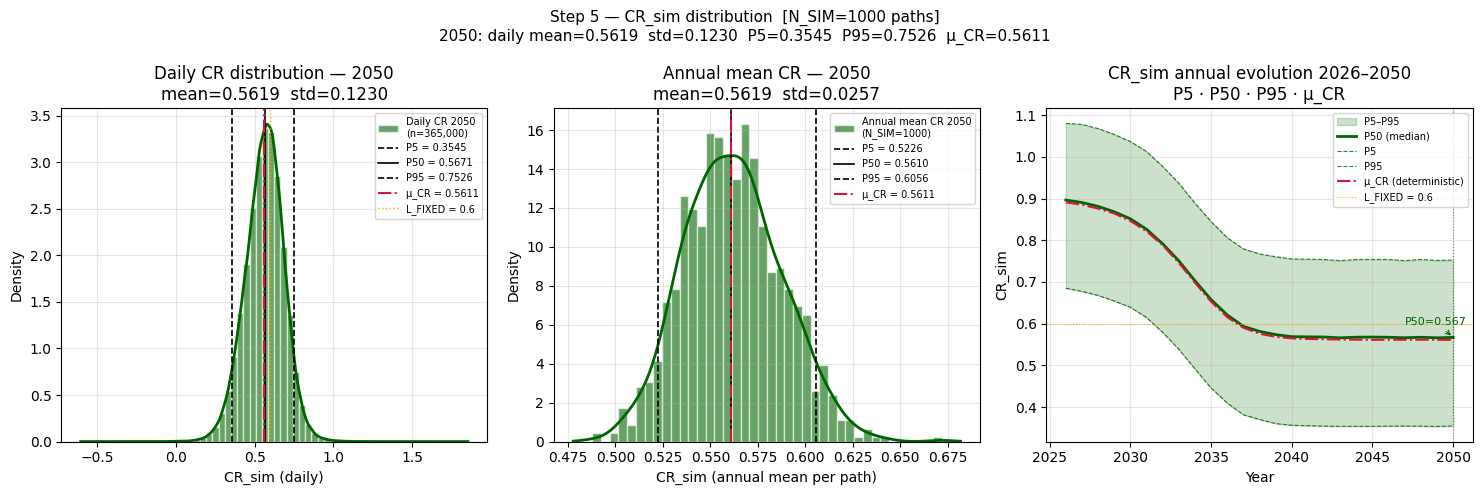

In [35]:
# ── CR_sim distribution for 2050 ─────────────────────────────────────────────
from scipy.stats import gaussian_kde

mask_2050    = df_cal["year"].values == 2050
CR_2050_daily = CR_sim[:, mask_2050]          # (N_SIM, days_in_2050)
CR_2050_flat  = CR_2050_daily.ravel()         # all daily values in 2050
CR_2050_mean  = CR_2050_daily.mean(axis=1)    # annual mean per path (N_SIM,)
mu_2050_mean  = float(mu_CR_sim[mask_2050].mean())

print(f"\n── CR_sim distribution — 2050 ───────────────────────────────────")
print(f"  μ_CR(2050) mean     = {mu_2050_mean:.4f}  (deterministic mean)")
print(f"  CR_sim daily mean   = {CR_2050_flat.mean():.4f}")
print(f"  CR_sim daily std    = {CR_2050_flat.std():.4f}")
print(f"  CR_sim annual mean  = {CR_2050_mean.mean():.4f}")
print(f"  CR_sim annual std   = {CR_2050_mean.std():.4f}")
print(f"\n  Daily CR_sim 2050:")
for pct in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"    P{pct:<3} = {np.percentile(CR_2050_flat, pct):.4f}")
print(f"    min  = {CR_2050_flat.min():.4f}")
print(f"    max  = {CR_2050_flat.max():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── left: daily CR distribution in 2050 ──────────────────────────────────────
ax = axes[0]
ax.hist(CR_2050_flat, bins=60, density=True,
        color="darkgreen", alpha=0.6, edgecolor="white",
        label=f"Daily CR 2050\n(n={len(CR_2050_flat):,})")

x_grid = np.linspace(CR_2050_flat.min() - 0.05,
                      CR_2050_flat.max() + 0.05, 300)
kde_d  = gaussian_kde(CR_2050_flat)
ax.plot(x_grid, kde_d(x_grid), color="darkgreen", lw=2.0)

for pct, ls, color in [
    ( 5,  "--", "black"),
    (50,  "-",  "black"),
    (95,  "--", "black"),
]:
    val = np.percentile(CR_2050_flat, pct)
    ax.axvline(val, color=color, lw=1.2, ls=ls,
               label=f"P{pct} = {val:.4f}")
ax.axvline(mu_2050_mean, color="crimson", lw=1.5, ls="-.",
           label=f"μ_CR = {mu_2050_mean:.4f}")
ax.axvline(L_FIXED, color="orange", lw=1.0, ls=":",
           label=f"L_FIXED = {L_FIXED}")

ax.set_xlabel("CR_sim (daily)")
ax.set_ylabel("Density")
ax.set_title(f"Daily CR distribution — 2050\n"
             f"mean={CR_2050_flat.mean():.4f}  "
             f"std={CR_2050_flat.std():.4f}")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# ── middle: annual mean CR distribution across paths ─────────────────────────
ax = axes[1]
ax.hist(CR_2050_mean, bins=40, density=True,
        color="darkgreen", alpha=0.6, edgecolor="white",
        label=f"Annual mean CR 2050\n(N_SIM={N_SIM})")

kde_a = gaussian_kde(CR_2050_mean)
x_ann = np.linspace(CR_2050_mean.min() - 0.01,
                     CR_2050_mean.max() + 0.01, 300)
ax.plot(x_ann, kde_a(x_ann), color="darkgreen", lw=2.0)

for pct, ls in [(5, "--"), (50, "-"), (95, "--")]:
    val = np.percentile(CR_2050_mean, pct)
    ax.axvline(val, color="black", lw=1.2, ls=ls,
               label=f"P{pct} = {val:.4f}")
ax.axvline(mu_2050_mean, color="crimson", lw=1.5, ls="-.",
           label=f"μ_CR = {mu_2050_mean:.4f}")

ax.set_xlabel("CR_sim (annual mean per path)")
ax.set_ylabel("Density")
ax.set_title(f"Annual mean CR — 2050\n"
             f"mean={CR_2050_mean.mean():.4f}  "
             f"std={CR_2050_mean.std():.4f}")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

# ── right: CR evolution 2026–2050 (annual P5, P50, P95) ──────────────────────
ax = axes[2]
years_sim = sorted(df_cal["year"].unique())
cr_p5_yr  = []
cr_p50_yr = []
cr_p95_yr = []
mu_yr     = []

for yr in years_sim:
    m = df_cal["year"].values == yr
    cr_p5_yr.append(float(np.percentile(CR_sim[:, m], 5)))
    cr_p50_yr.append(float(np.percentile(CR_sim[:, m], 50)))
    cr_p95_yr.append(float(np.percentile(CR_sim[:, m], 95)))
    mu_yr.append(float(mu_CR_sim[m].mean()))

ax.fill_between(years_sim, cr_p5_yr, cr_p95_yr,
                alpha=0.20, color="darkgreen", label="P5–P95")
ax.plot(years_sim, cr_p50_yr, color="darkgreen", lw=2.0,
        label="P50 (median)")
ax.plot(years_sim, cr_p5_yr,  color="darkgreen", lw=0.8,
        ls="--", alpha=0.8, label="P5")
ax.plot(years_sim, cr_p95_yr, color="darkgreen", lw=0.8,
        ls="--", alpha=0.8, label="P95")
ax.plot(years_sim, mu_yr, color="crimson", lw=1.5, ls="-.",
        label="μ_CR (deterministic)")
ax.axhline(L_FIXED, color="orange", lw=0.8, ls=":",
           label=f"L_FIXED = {L_FIXED}")

# highlight 2050
ax.axvline(2050, color="black", lw=0.8, ls=":", alpha=0.5)
ax.annotate(f"P50={cr_p50_yr[-1]:.3f}",
            xy=(2050, cr_p50_yr[-1]),
            xytext=(2047, cr_p50_yr[-1] + 0.03),
            fontsize=8, color="darkgreen",
            arrowprops=dict(arrowstyle="->", color="darkgreen", lw=0.8))

ax.set_xlabel("Year")
ax.set_ylabel("CR_sim")
ax.set_title("CR_sim annual evolution 2026–2050\n"
             "P5 · P50 · P95 · μ_CR")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

plt.suptitle(
    f"Step 5 — CR_sim distribution  [N_SIM={N_SIM} paths]\n"
    f"2050: daily mean={CR_2050_flat.mean():.4f}  "
    f"std={CR_2050_flat.std():.4f}  "
    f"P5={np.percentile(CR_2050_flat,5):.4f}  "
    f"P95={np.percentile(CR_2050_flat,95):.4f}  "
    f"μ_CR={mu_2050_mean:.4f}",
    fontsize=11
)
plt.tight_layout()
plt.show()


── Step 6: Save physical variables ─────────────────────────────
  Saved  : ..\..\Data\Simulated\mc_physical_variables.parquet
  Rows   : 9,131,000
  Size   : 220.9 MB
  Cols   : ['sim_id', 'date', 'T_sim', 'GHI_sim', 'KT_sim', 'CR_sim', 'year', 'month', 'doy', 'pen_scenario', 'mu_CR_sim', 'ghi_clearsky']

  Read-back:
    Rows    : 9,131,000  ✓
    sim_id  : 1000 unique
    T_sim   : 14.62°C
    GHI_sim : 4124 Wh/m²
    CR_sim  : 0.6640


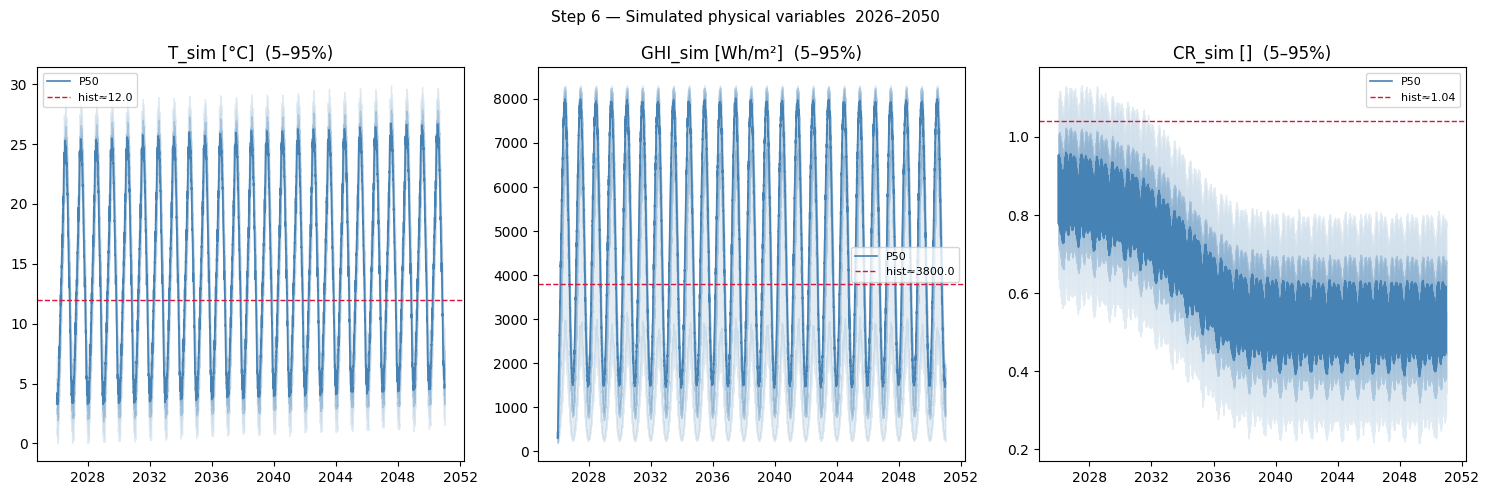


── Steps 1–6 complete ───────────────────────────────────────────
  Solar pipeline : logit (α=-0.001, β=0.9113407945329784)  → ARMA(2,1) → Y_bar(t_abs) → Kt → GHI
  → Next: compute T_eff, f_temp, P(t), RI(t)


In [33]:
# STEP 6 — Save physical variables to parquet
# ─────────────────────────────────────────────────────────────────────────────
 
print(f"\n── Step 6: Save physical variables ─────────────────────────────")
 
dates_rep   = np.tile(dates_sim, N_SIM)
sim_ids     = np.repeat(np.arange(N_SIM), N_DAYS)
 
df_physical = pd.DataFrame({
    "sim_id":   sim_ids.astype(np.int32),
    "date":     dates_rep,
    "T_sim":    T_sim.ravel().astype(np.float32),
    "GHI_sim":  GHI_sim.ravel().astype(np.float32),
    "KT_sim":   KT_sim.ravel().astype(np.float32),
    "CR_sim":   CR_sim.ravel().astype(np.float32),
})
 
df_cal_merge = df_cal[["date","year","month","doy",
                         "pen_scenario","mu_CR_sim","ghi_clearsky"]].copy()
df_cal_merge["date"] = pd.to_datetime(df_cal_merge["date"])
df_physical["date"]  = pd.to_datetime(df_physical["date"])
df_physical = df_physical.merge(df_cal_merge, on="date", how="left")
 
out_file = output_path / "mc_physical_variables.parquet"
df_physical.to_parquet(out_file, index=False, compression="snappy")
 
file_mb = out_file.stat().st_size / 1e6
print(f"  Saved  : {out_file}")
print(f"  Rows   : {len(df_physical):,}")
print(f"  Size   : {file_mb:.1f} MB")
print(f"  Cols   : {list(df_physical.columns)}")
 
# read-back check
df_check = pd.read_parquet(out_file)
ok = len(df_check) == N_SIM * N_DAYS
print(f"\n  Read-back:")
print(f"    Rows    : {len(df_check):,}  {'✓' if ok else '✗'}")
print(f"    sim_id  : {df_check['sim_id'].nunique()} unique")
print(f"    T_sim   : {df_check['T_sim'].mean():.2f}°C")
print(f"    GHI_sim : {df_check['GHI_sim'].mean():.0f} Wh/m²")
print(f"    CR_sim  : {df_check['CR_sim'].mean():.4f}")
 
# validation fan charts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, arr, label, unit, ref in [
    (axes[0], T_sim,   "T_sim",   "°C",   12.0),
    (axes[1], GHI_sim, "GHI_sim", "Wh/m²",3800.0),
    (axes[2], CR_sim,  "CR_sim",  "",      1.04),
]:
    p5  = np.percentile(arr,  5, axis=0)
    p25 = np.percentile(arr, 25, axis=0)
    p50 = np.percentile(arr, 50, axis=0)
    p75 = np.percentile(arr, 75, axis=0)
    p95 = np.percentile(arr, 95, axis=0)
    ax.fill_between(dates_pd, p5,  p95,  alpha=0.15, color="steelblue")
    ax.fill_between(dates_pd, p25, p75,  alpha=0.30, color="steelblue")
    ax.plot(dates_pd, p50, color="steelblue", lw=1.2, label="P50")
    ax.axhline(ref, color="crimson", lw=1.0, ls="--", label=f"hist≈{ref}")
    ax.set_title(f"{label} [{unit}]  (5–95%)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(fontsize=8)
 
plt.suptitle("Step 6 — Simulated physical variables  2026–2050", fontsize=11)
plt.tight_layout()
plt.show()
 
print(f"\n── Steps 1–6 complete ───────────────────────────────────────────")
print(f"  Solar pipeline : logit (α={alpha_kt}, β={beta_kt})  "
      f"→ ARMA(2,1) → Y_bar(t_abs) → Kt → GHI")
print(f"  → Next: compute T_eff, f_temp, P(t), RI(t)")

In [34]:
df_physical.head(5)

,sim_id,date,T_sim,GHI_sim,KT_sim,CR_sim,year,month,doy,pen_scenario,mu_CR_sim,ghi_clearsky
0,0,2026-01-01,3.829343,448.164978,0.232656,0.980419,2026,1,1,1.023232,0.947060,1926.299051
1,0,2026-01-02,3.565300,325.310516,0.165366,1.108800,2026,1,2,1.023257,0.947462,1967.217525
2,0,2026-01-03,2.977519,192.867218,0.096051,1.020965,2026,1,3,1.023282,0.844113,2007.975115
3,0,2026-01-04,2.827906,302.442322,0.150090,0.878646,2026,1,4,1.023308,0.783158,2015.077007
4,0,2026-01-05,1.691335,1859.528564,0.920021,0.997883,2026,1,5,1.023333,0.948502,2021.179681
